
## Analyse des Diamanten-Datensatzes

### Notwendige Bibliotheken importieren

In [19]:
import pandas as pd
import matplotlib.pyplot as plt

### Einlesen des Datensatzes

In [20]:
diamonds_dataframe = pd.read_csv('diamonds.csv')

### Exploration

In [21]:
diamonds_dataframe.head()

,Unnamed: 0,carat,cut,color,clarity,depth,table,price,x,y,z
0,1,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,2,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,3,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,4,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,5,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [22]:
diamonds_dataframe.shape

(53940, 11)

Entfernen der überflüssigen Spalte

In [23]:
diamonds_dataframe.drop('Unnamed: 0', axis=1, inplace=True)
#dropped_dataframe = diamonds_dataframe.drop('Unnamed: 0', axis=1)

diamonds_dataframe.head()
#dropped_dataframe.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


### Info des Dataframes

In [24]:
diamonds_dataframe.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   carat    53940 non-null  float64
 1   cut      53940 non-null  object 
 2   color    53940 non-null  object 
 3   clarity  53940 non-null  object 
 4   depth    53940 non-null  float64
 5   table    53940 non-null  float64
 6   price    53940 non-null  int64  
 7   x        53940 non-null  float64
 8   y        53940 non-null  float64
 9   z        53940 non-null  float64
dtypes: float64(6), int64(1), object(3)
memory usage: 4.1+ MB


### Detailbeschreibung
* Numerische Werte

In [46]:
diamonds_dataframe.describe()

,carat,depth,table,price,x,y,z
count,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000
mean,0.797940,61.749405,57.457184,3932.799722,5.731157,5.734526,3.538734
std,0.474011,1.432621,2.234491,3989.439738,1.121761,1.142135,0.705699
min,0.200000,43.000000,43.000000,326.000000,0.000000,0.000000,0.000000
25%,0.400000,61.000000,56.000000,950.000000,4.710000,4.720000,2.910000
50%,0.700000,61.800000,57.000000,2401.000000,5.700000,5.710000,3.530000
75%,1.040000,62.500000,59.000000,5324.250000,6.540000,6.540000,4.040000
max,5.010000,79.000000,95.000000,18823.000000,10.740000,58.900000,31.800000


* Sind die object-Spalten kategorische Variablen?
  * Kategorien enthalten halt nur eine eher beschränkte Menge von unterschiedlichen Werten

In [47]:
diamonds_dataframe['cut'].describe()

count     53940
unique        5
top       Ideal
freq      21551
Name: cut, dtype: object

* Ergebnis
  * Die object-Spalten (cut, color, clarity) dieses Datensatzes sind allesamt kategorisch
    * Damit kann sinnvoll nach diesen Spalten gruppiert werden

## Cleanup

### Einführen von kategorisierten Spalten

In [60]:
categorical_cut = pd.Categorical(diamonds_dataframe['cut'])
diamonds_dataframe['cut'] = categorical_cut
diamonds_dataframe.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype   
---  ------   --------------  -----   
 0   carat    53940 non-null  float64 
 1   cut      53940 non-null  category
 2   color    53940 non-null  object  
 3   clarity  53940 non-null  object  
 4   depth    53940 non-null  float64 
 5   table    53940 non-null  float64 
 6   price    53940 non-null  int64   
 7   x        53940 non-null  float64 
 8   y        53940 non-null  float64 
 9   z        53940 non-null  float64 
dtypes: category(1), float64(6), int64(1), object(2)
memory usage: 3.8+ MB


Histogramm auf Basis des Gewichts

array([[<Axes: title={'center': 'carat'}>]], dtype=object)

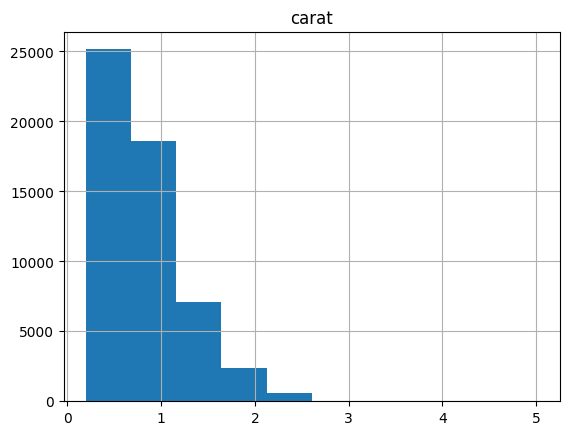

In [49]:
diamonds_dataframe.hist(column='carat')

### Histogramm mit 20 Bins, das die Diamanten mit einem Gewicht > 3.5 darstellt

array([[<Axes: title={'center': 'carat'}>]], dtype=object)

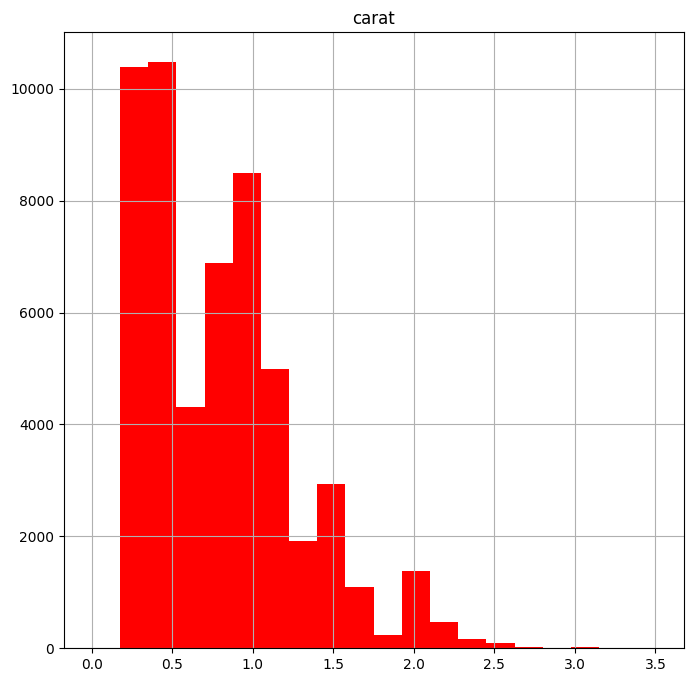

In [50]:
diamonds_dataframe.hist(column="carat",
              figsize=(8,8),         
              color="red",          
              bins=20,               
              range= (0,3.5))

array([[<Axes: title={'center': 'carat'}>]], dtype=object)

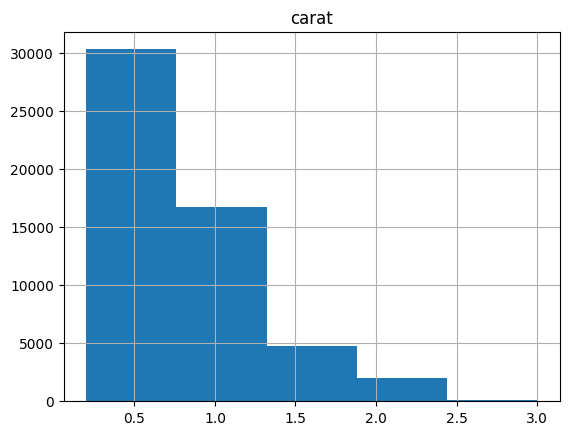

In [51]:
diamonds_dataframe[diamonds_dataframe['carat'] <= 3.0].hist(column='carat', bins=5)

array([[<Axes: title={'center': 'price'}>]], dtype=object)

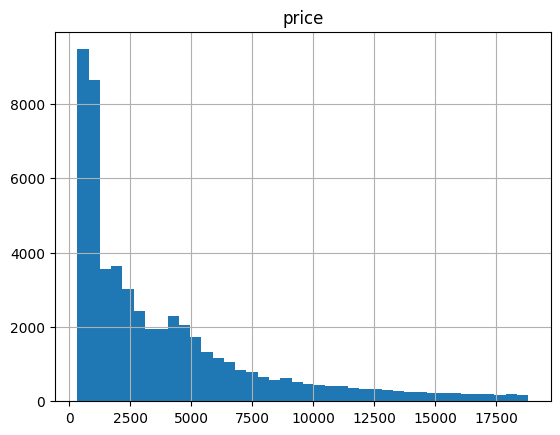

In [52]:
# diamonds_dataframe.hist(column='clarity') # no histogram for non-numerics
diamonds_dataframe.hist(column='price', bins=40)

### Statistische Analyse des Datensatzes

In [53]:
diamonds_dataframe.describe()

,carat,depth,table,price,x,y,z
count,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000
mean,0.797940,61.749405,57.457184,3932.799722,5.731157,5.734526,3.538734
std,0.474011,1.432621,2.234491,3989.439738,1.121761,1.142135,0.705699
min,0.200000,43.000000,43.000000,326.000000,0.000000,0.000000,0.000000
25%,0.400000,61.000000,56.000000,950.000000,4.710000,4.720000,2.910000
50%,0.700000,61.800000,57.000000,2401.000000,5.700000,5.710000,3.530000
75%,1.040000,62.500000,59.000000,5324.250000,6.540000,6.540000,4.040000
max,5.010000,79.000000,95.000000,18823.000000,10.740000,58.900000,31.800000


<Axes: >

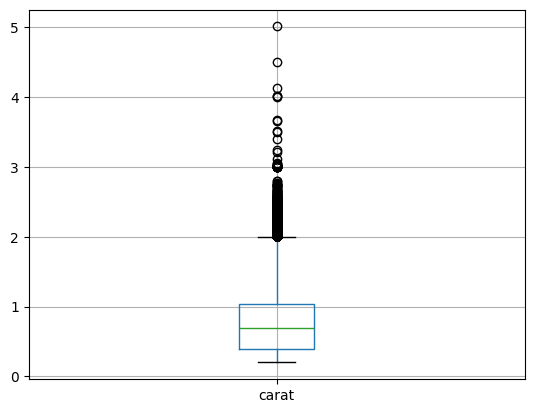

In [54]:
diamonds_dataframe.boxplot(column="carat")

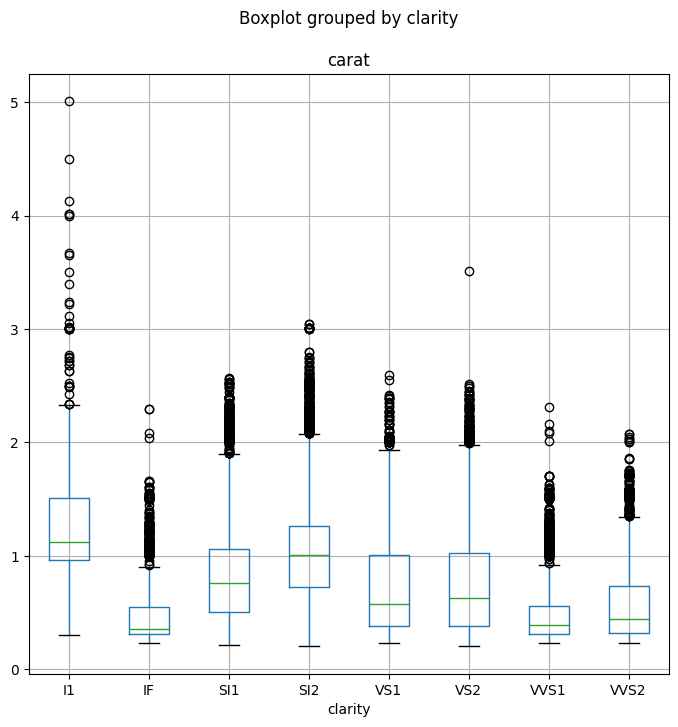

In [55]:
diamonds_dataframe.boxplot(column="carat",        # Column to plot
                 by= "clarity",         # Column to split upon
                 figsize= (8,8));       # Figure size